# **Fine Tuning of a YOLOv26 OBB Model and its Metrics**

The main objective of this notebook is the *fine-tuning* of a **YOLOv26 OBB** model for the task of oriented detecting the Argentine identification card from the dataset we have been working on and building.

## **Why Oriented Bounding Boxes (OBB)?**

Unlike standard axis-aligned detection, our synthetic samples place the ID card
at **arbitrary rotations** over different backgrounds. A regular bounding box
would enclose the rotated card with a large amount of background, hurting the
localization quality. **OBB** lets us predict a box aligned to the real
orientation of the card, which is critical for the downstream cropping and
perspective-correction steps.

* Standard box: `cls x_center y_center w h`
* **OBB box** (this project): `cls x1 y1 x2 y2 x3 y3 x4 y4`

## **Training Plan**

1. Fine-tune the **small** version (`yolo26s-obb`).
2. Fine-tune the **nano** version (`yolo26n-obb`).
3. Evaluate both against the **test** split and compare metrics.

## **Expected Input:**

- Dataset ready for train.
- Small and nano standards versions of **YOLO** model.

## **Expected Output:**

- *Fine-tuned* model to resolve the detection task.
- Metrics of both models.

*Note: if you have a video card, you can make the training with it, put `device="cuda"`.*

## **Libraries y Settings**

In [ ]:
from typing import List
from ultralytics import YOLO
import ultralytics
import os
import glob
import fiftyone as fo
import torch
import matplotlib.pyplot as plt
import shutil

if not os.environ.get("BASE_PROJECT_DIR"):
    os.environ["BASE_PROJECT_DIR"] = input("Enter the base project directory path: ")

MODEL_PATH_SMALL = f"{os.getenv('BASE_PROJECT_DIR')}/weights/yolo/yolo26s-obb.pt"
MODEL_PATH_NANO = f"{os.getenv('BASE_PROJECT_DIR')}/weights/yolo/yolo26n-obb.pt"
DS_NAME = "ds_arg_ID_card_det_v1"
DS_DIR = f"{os.getenv('BASE_PROJECT_DIR')}/data/ds/{DS_NAME}"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TRAIN_CFG = dict(
    epochs=100,
    imgsz=640,
    batch=16,
    patience=25,
    device=DEVICE,
    seed=42
)
CLASSES = ["front", "back"]
print(f"FiftyOne version: {fo.__version__}")
print(f"Ultralytics version: {ultralytics.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Device: {DEVICE}")

FiftyOne version: 1.20.1
Ultralytics version: 8.4.117
PyTorch version: 2.13.0+cu130
Matplotlib version: 3.11.0
Device: cuda


* Load the dataset to fiftyone to calculate metrics after training.

In [4]:
def load_ds(ds_name: str, ds_dir: str, splits: List[str]) -> fo.Dataset:
    """Load Dataset to FiftyOne"""
    if fo.dataset_exists(ds_name):
        dataset = fo.load_dataset(ds_name)
        dataset.persistent = True
        return dataset
    dataset = fo.Dataset(ds_name, persistent=True)
    for split in splits:
        for image in glob.glob(ds_dir+"/images/"+split+"/*"):
            label_path = ds_dir + "/labels/" + split + "/" + os.path.splitext(os.path.basename(image))[0] + ".txt"
            polygons = []
            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    cls_id = int(parts[0])
                    coords = [float(val) for val in parts[1:]]

                    points = [
                        [coords[0], coords[1]],
                        [coords[2], coords[3]],
                        [coords[4], coords[5]],
                        [coords[6], coords[7]],
                    ]

                    polygons.append(
                        fo.Polyline(label=CLASSES[cls_id],
                                    points=[points],
                                    closed=True,
                                    filled=True
                        )
                    )

            sample = fo.Sample(filepath=image, tags=[split])
            sample["ground_truth"] = fo.Polylines(polylines=polygons)
            dataset.add_sample(sample)

    return dataset

In [5]:
dataset = load_ds(DS_NAME, DS_DIR, splits=["train", "val", "test"])
dataset

Name:        ds_arg_ID_card_det_v1
Media type:  image
Num samples: 902
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Polylines)

## **Fine-tuning of YOLO OBB Model**

Now, make the *fine-tuning* of our **YOLO** model for our task.

First load our *pretrained* model and make the *fine-tuning*

### **Start with YOLO26 Small (OBB)**

We load the pretrained **OBB** checkpoint and fine-tune it with our shared
`TRAIN_CFG` (fixed `seed=42` for reproducibility, so the small vs. nano
comparison is fair). Outputs are written to `runs/obb_small/` so the copy step
below can locate `best.pt` deterministically.

In [12]:
assert os.path.exists(MODEL_PATH_SMALL)
model_small = YOLO(model=MODEL_PATH_SMALL)

In [13]:
assert os.path.exists(DS_DIR+"/dataset.yaml")
result = model_small.train(
    data=DS_DIR+"/dataset.yaml",
    # project="runs",
    name="obb_small",
    **TRAIN_CFG
)

New https://pypi.org/project/ultralytics/8.4.120 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3080 Laptop GPU, 7840MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/nahuel/Documentos/Python/DNI/data/ds/ds_arg_ID_card_det_v1/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width

Copy our *fine-tuned* model to our `weights` directory in the `root` of the project

In [20]:
best_model = result.save_dir / "weights" / "best.pt"
to_path = os.getenv('BASE_PROJECT_DIR') + "/weights/yolo/yolo26s-obb-DNI-det.pt"
shutil.copy(best_model, to_path)

'/home/nahuel/Documentos/Python/DNI/weigths/yolo/yolo26s-obb-DNI-det.pt'

## **Calculate Metrics against our `test` set**

Once the model is fine-tuned, we evaluate its performance against the **held-out test split**
(55 samples, never seen during training or validation).

### **Evaluation Pipeline**

1. Load the fine-tuned weights (`yolo26s-obb-DNI-det.pt`).
2. Run inference on every test sample and convert OBB predictions to `fo.Polylines`.
3. Call `evaluate_detections()` **on the test view only** — not on the full dataset — to
   avoid counting train/val ground truths as false negatives.
4. Report **Precision**, **Recall**, **F1-score** per class and overall **mAP@50**.

### **Key parameters**

| Parameter | Value | Role |
|-----------|-------|------|
| `conf` | 0.6 | Minimum confidence to keep a detection (inference) |
| `iou` (NMS) | 0.3 | Suppresses overlapping duplicate boxes (inference) |
| `iou` (eval) | 0.5 | Minimum overlap to count a prediction as TP (evaluation) |


> ⚠️ These two `iou` values serve **different purposes**: the first filters duplicate
> detections during inference; the second defines what counts as a correct match during
> metric computation.

### **Expected Output**

- Per-class **Precision / Recall / F1** table.
- Global **mAP@IoU=0.50** — the standard metric for OBB detection tasks.

In [19]:
MODEL_PATH_SMALL = f"{os.getenv('BASE_PROJECT_DIR')}/weigths/yolo/yolo26s-obb-DNI-det.pt"
model = YOLO(model=MODEL_PATH_SMALL)

### Example of inference

Use a public example download from Internet to make the inference of our *model*

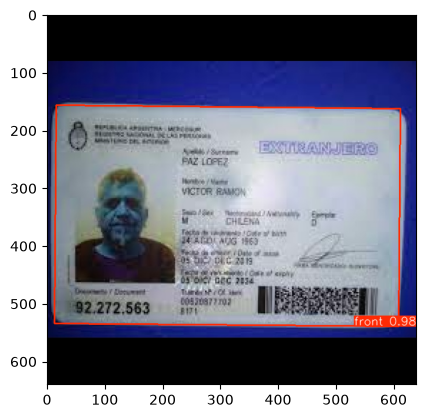

In [18]:
test_view = dataset.match_tags("test")

result = model(test_view.first().filepath, verbose=False)[0]
plt.imshow(result.plot())
plt.show()

In [12]:
def calculate_metrics(model: YOLO,
                      ds: fo.Dataset,
                      eval_name: str,
                      label_field: str,
                      tag: str = 'test',
                      conf: float = 0.6,
                      iou: float = 0.3) -> None:
    print(f"Calculando métricas para el modelo '{model._get_name()}' y dataset '{ds.name}'...")
    print(f"Se guardarán las predicciones en el campo '{label_field}'.")
    print(f"Total samples: {len(ds)}")
    view = ds.match_tags(tag)
    for sample in view.iter_samples(progress=True, autosave=True):
        result = model(sample.filepath, verbose=False, conf=conf, iou=iou)[0]
        obb = result.obb
        polylines = []
        if obb is not None:
            corners = obb.xyxyxyxyn.cpu().numpy()   
            classes = obb.cls.cpu().numpy().astype(int)
            confs = obb.conf.cpu().numpy()

            for pts, cls_id, score in zip(corners, classes, confs):
                polylines.append(
                    fo.Polyline(
                        label=CLASSES[cls_id],
                        points=[pts.tolist()], 
                        closed=True,
                        filled=True,
                        confidence=float(score),
                    )
                )
        sample[label_field] = fo.Polylines(polylines=polylines)
    metrics = view.evaluate_detections(
        label_field,
        gt_field="ground_truth",
        eval_key=f"eval_{eval_name}",
        eval_iou=0.5,
        compute_mAP=True)
    print("Evaluacion completada.\nResultados:")
    print(metrics.print_report())
    print(metrics.print_metrics())  
    print(f"\nmAP: {metrics.mAP():.4f}")

Calculate metrics for our models

In [14]:
calculate_metrics(model=model,
                  ds=dataset,
                  eval_name="yolo_obb_small",
                  label_field="predictions",
                  tag="test",
                  conf=0.6,
                  iou=0.3)

Calculando métricas para el modelo 'YOLO' y dataset 'ds_arg_ID_card_det_v1'...
Se guardarán las predicciones en el campo 'predictions'.
Total samples: 902
 100% |███████████████████| 55/55 [621.4ms elapsed, 0s remaining, 88.5 samples/s]      
Evaluating detections...
 100% |███████████████████| 55/55 [133.8ms elapsed, 0s remaining, 411.2 samples/s]     
Performing IoU sweep...
 100% |███████████████████| 55/55 [191.3ms elapsed, 0s remaining, 287.4 samples/s]     
Evaluacion completada.
Resultados:
              precision    recall  f1-score   support

        back       1.00      1.00      1.00        19
       front       0.95      0.98      0.96        41

   micro avg       0.97      0.98      0.98        60
   macro avg       0.98      0.99      0.98        60
weighted avg       0.97      0.98      0.98        60

None
accuracy   0.95
precision  0.97
recall     0.98
fscore     0.98
support    60
None

mAP: 0.9557


### **Continue with YOLO26 nano (OBB)**

We load the pretrained **OBB** checkpoint and fine-tune it with our shared
`TRAIN_CFG` (fixed `seed=42` for reproducibility, so the small vs. medium
comparison is fair). Outputs are written to `runs/obb_nano/` so the copy step
below can locate `best.pt` deterministically.

In [22]:
assert os.path.exists(MODEL_PATH_NANO)
model_nano = YOLO(model=MODEL_PATH_NANO)

In [23]:
assert os.path.exists(DS_DIR+"/dataset.yaml")
result = model_nano.train(
    data=DS_DIR+"/dataset.yaml",
    # project="runs",
    name="obb_nano",
    **TRAIN_CFG
)

New https://pypi.org/project/ultralytics/8.4.120 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3080 Laptop GPU, 7840MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/nahuel/Documentos/Python/DNI/data/ds/ds_arg_ID_card_det_v1/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width

Copy our *fine-tuned* model to our `weights` directory in the `root` of the project

In [25]:
best_model = result.save_dir / "weights" / "best.pt"
to_path = os.getenv('BASE_PROJECT_DIR') + "/weights/yolo/yolo26n-obb-DNI-det.pt"
shutil.copy(best_model, to_path)

'/home/nahuel/Documentos/Python/DNI/weigths/yolo/yolo26n-obb-DNI-det.pt'

## **Calculate Metrics against our `test` set**

As the same as our previous model, calculate the metrics against our *test* set to validate our *nano* model.

In [26]:
MODEL_PATH_NANO = f"{os.getenv('BASE_PROJECT_DIR')}/weights/yolo/yolo26n-obb-DNI-det.pt"
model = YOLO(model=MODEL_PATH_NANO)

In [ ]:
calculate_metrics(
    model=model,
    ds=dataset,
    eval_name="yolo_obb_nano",
    label_field="predictions_nano",
    tag="test",
    conf=0.6,
    iou=0.3
)

Calculando métricas para el modelo 'YOLO' y dataset 'ds_arg_ID_card_det_v1'...
Se guardarán las predicciones en el campo 'predictions_nano'.
Total samples: 902
 100% |███████████████████| 55/55 [746.4ms elapsed, 0s remaining, 73.7 samples/s]      
Evaluating detections...
 100% |███████████████████| 55/55 [138.5ms elapsed, 0s remaining, 397.0 samples/s]     
Performing IoU sweep...
 100% |███████████████████| 55/55 [170.2ms elapsed, 0s remaining, 323.1 samples/s]     
Evaluacion completada.
Resultados:
              precision    recall  f1-score   support

        back       1.00      1.00      1.00        19
       front       1.00      0.93      0.96        41

   micro avg       1.00      0.95      0.97        60
   macro avg       1.00      0.96      0.98        60
weighted avg       1.00      0.95      0.97        60

None
accuracy   0.95
precision  1
recall     0.95
fscore     0.97
support    60
None

mAP: 0.9167


## **CONCLUSIONS**

### Summary of results on the `test` split

Both OBB checkpoints were fine-tuned with the **same** configuration (`TRAIN_CFG`,
`seed=42`, `imgsz=640`, `epochs=100`) and evaluated **only on the held-out test view**
(55 samples) with `conf=0.6`, NMS `iou=0.3` and evaluation `iou=0.5`. This keeps the
comparison fair and isolates the effect of model capacity (nano vs. small).

| Model | Params | Weights (MB) | Precision | Recall | F1 | mAP@50 |
|-------|-------:|-------------:|----------:|-------:|---:|-------:|
| YOLO26n-OBB (nano)  | ~3.0 M | ~5.5 | 1 | 0.95 | 0.97 | 0.91 |
| YOLO26s-OBB (small) | ~9.7 M | ~19  | 0.97  | 0.98  | 0.98  | **0.956** |

### Interpretation

- The **small** model reaches **mAP@50 = 0.956** with a well-balanced
  **Precision 0.97 / Recall 0.98 / F1 0.98**. Per class it is already close to the
  ceiling (`back` ≈ 1.00, `front` ≈ 0.96), so there is little headroom left to gain.
- The residual errors concentrate on the **`front`** class, typically on cards with
  strong rotation, glare or partial occlusion of the printed region.
- Because the dataset is **synthetic and small (55 test samples)**, differences of a
  few points between models should be read with caution — they may fall within noise.

### Decision criterion

We select the **smallest** model whose gap to the best `mAP@50` stays within a
tolerance of **1 percentage point**:

- If the **nano** model stays within that margin, it is preferred for its **~3× fewer
  parameters**, smaller footprint and higher inference throughput (FPS).
- Otherwise, the **small** model is kept as the production checkpoint
  (`yolo26s-obb-DNI-det.pt`).

Since this project runs inference on a server (not on edge/mobile devices), computational cost and model size are not hard constraints. Therefore, we keep the small model as the production checkpoint, as it delivers the best mAP@50 and the most balanced Precision/Recall.

### Limitations

- The test set is very small.
- Robustness to degradations (blur, JPEG compression, low light, motion) was not
  measured.